<div style="background:linear-gradient(120deg,#0a2a5c,#1c5aa6);color:#fff;padding:22px 26px;border-radius:12px;border-bottom:5px solid #d49a2a;">
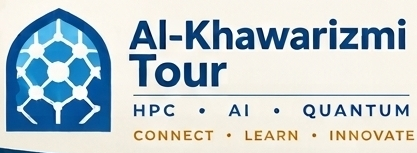
<p style="color:#ffd98e;letter-spacing:.14em;font-size:12px;font-weight:700;margin:12px 0 4px;">AL-KHAWARIZMI TOUR · ONLINE HACKATHON HPC &amp; AI · OCT 3 – NOV 7, 2026 · LECTURE 1 NOTEBOOK</p>
<h1 style="color:#fff;margin:4px 0 6px;border:none;">Data Quality &amp; Preprocessing — Beijing Air Quality · Hands-on &amp; Week-1 Team Challenge</h1>
<p style="color:#e6eef8;margin:0;">Part A: guided demos used during the lecture (slide references in each heading) · Part B: the week-long <b>Air-Quality Data Challenge</b></p>
<p style="color:#ffd98e;margin:10px 0 0;font-style:italic;">Connect · Learn · Innovate — Instructor: Dr. Rafik Borji</p></div>

## How to use this notebook

| Part | When | What |
|---|---|---|
| **A · Guided demos** (A1–A11) | during the 2-hour lecture | each demo matches a slide of the deck / a card of the speaker script |
| **B · Team challenge** (Tasks 1–6 + ★ bonus) | the whole week | fill in the `# TODO` cells, write your report, prepare your pitch |

**Dataset:** *Beijing Multi-Site Air Quality* — UCI Machine Learning Repository, dataset 501. Hourly PM2.5, PM10, SO2, NO2, CO, O3 (µg/m³) and TEMP, PRES, DEWP, RAIN, wind direction `wd`, wind speed `WSPM` at **12 stations**, **1 Mar 2013 – 28 Feb 2017**, **420,768 rows**, with real missing values (NA).
Reference: Zhang, S. et al. (2017) *Cautionary tales on air-quality improvement in Beijing*, Proc. R. Soc. A.

**Data access:** the notebook downloads the archive from UCI (≈ 8 MB) and caches it. If you already have the `PRSA_Data_*.csv` files, put them next to the notebook. Offline, a synthetic stand-in with the same columns is generated so the code still runs.

**Requirements:** Python ≥ 3.9, `numpy`, `pandas`, `matplotlib`, `scikit-learn ≥ 1.2`. Works in Jupyter, VS Code or Google Colab. Tip: on a laptop, run Part A first on `SAMPLE_STATIONS` (4 stations) and switch to all 12 for the challenge.

## 0 · Setup — set your team number first

In [2]:
TEAM_ID = 1            # <-- your team number: it seeds YOUR version of the merged dataset
SEED = 1000 + TEAM_ID

import time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": .3})
rng = np.random.default_rng(SEED)
import sklearn; print("scikit-learn", sklearn.__version__, "| team", TEAM_ID)

scikit-learn 1.6.1 | team 1


---
# Part A · Guided demos
## A1 · Load the 12 station files  *(slides 2 & 13)*

In [3]:
import io, os, glob, ssl, zipfile, urllib.request

STATIONS = ["Aotizhongxin", "Changping", "Dingling", "Dongsi", "Guanyuan", "Gucheng", "Huairou",
            "Nongzhanguan", "Shunyi", "Tiantan", "Wanliu", "Wanshouxigong"]
WD = ["N", "NNE", "NE", "ENE", "E", "ESE", "SE", "SSE", "S", "SSW", "SW", "WSW", "W", "WNW", "NW", "NNW"]
POLLUTANTS = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3"]
WEATHER = ["TEMP", "PRES", "DEWP", "RAIN", "WSPM"]
KEY = ["station", "year", "month", "day", "hour"]
URL = "https://archive.ics.uci.edu/static/public/501/beijing+multi+site+air+quality+data.zip"
CACHE = "beijing_air_quality_raw.csv.gz"

def _csvs_from_zip(blob):
    """The UCI archive contains a nested zip with one CSV per station -> read them all."""
    frames = []
    with zipfile.ZipFile(io.BytesIO(blob)) as z:
        for name in z.namelist():
            if name.lower().endswith(".zip"):
                frames += _csvs_from_zip(z.read(name))
            elif name.lower().endswith(".csv") and "PRSA_Data" in os.path.basename(name):
                frames.append(pd.read_csv(io.BytesIO(z.read(name))))
    return frames

def _download(url):
    try:
        return urllib.request.urlopen(url, timeout=180).read()
    except Exception:
        return urllib.request.urlopen(url, timeout=180, context=ssl._create_unverified_context()).read()

def synthetic_beijing(seed=0):
    """Offline stand-in with the same columns, 12 stations, seasonal/diurnal cycles and runs of missing values.
    Used ONLY if neither local files nor the UCI download are available."""
    r = np.random.default_rng(seed)
    t = pd.date_range("2013-03-01 00:00", "2017-02-28 23:00", freq="h")
    n, doy, hr = len(t), t.dayofyear.values, t.hour.values
    season = np.cos(2 * np.pi * (doy - 15) / 365.25)                 # +1 in mid-January (heating season)
    e = r.normal(0, 1, n); z = np.zeros(n)
    for i in range(1, n):                                            # regional stagnation index, AR(1)
        z[i] = 0.985 * z[i - 1] + 0.17 * e[i]
    frames = []
    for k, st in enumerate(STATIONS):
        urb = 1.0 if st in ["Dongsi", "Guanyuan", "Gucheng", "Nongzhanguan", "Tiantan", "Wanshouxigong", "Aotizhongxin", "Wanliu"] else 0.0
        TEMP = 13 - 15 * season + 4 * np.sin(2 * np.pi * (hr - 9) / 24) + r.normal(0, 2, n) - (1 - urb)
        DEWP = TEMP - np.clip(r.gamma(2, 4, n) - 3 * z, 0.5, 35)
        PRES = 1012 + 12 * season + r.normal(0, 3, n)
        WSPM = np.clip(r.gamma(2, 0.9, n) - 0.4 * z, 0, None)
        ang = (np.where(z < 0, 315, 180) + r.normal(0, 50, n)) % 360
        wd = np.array(WD)[np.round(ang / 22.5).astype(int) % 16]
        RAIN = np.where(r.random(n) < 0.03 * (1 - season), r.exponential(1.5, n), 0.0)
        logpm = 3.8 + 0.35 * season + 0.9 * z + 0.15 * urb + 0.2 * np.cos(2 * np.pi * (hr - 22) / 24) - 0.15 * WSPM + r.normal(0, .25, n)
        PM25 = np.clip(np.exp(logpm), 3, 900)
        PM10 = PM25 * (1.15 + r.gamma(2, 0.2, n))
        CO = np.clip(300 + 11 * PM25 * (1 + .3 * season) + r.normal(0, 150, n), 100, None)
        NO2 = np.clip(20 + .35 * PM25 ** .8 + 10 * urb + r.normal(0, 8, n), 2, None)
        SO2 = np.clip(3 + 25 * np.clip(season, 0, None) * np.exp(.5 * z) + r.normal(0, 3, n), 2, None)
        O3 = np.clip(10 + 60 * (1 - season) / 2 * 2 * np.clip(np.sin(2 * np.pi * (hr - 8) / 24), 0, None) - .2 * NO2 + r.normal(0, 10, n), 2, None)
        f = pd.DataFrame({"No": np.arange(1, n + 1), "year": t.year, "month": t.month, "day": t.day, "hour": hr,
                          "PM2.5": PM25, "PM10": PM10, "SO2": SO2, "NO2": NO2, "CO": CO, "O3": O3,
                          "TEMP": TEMP, "PRES": PRES, "DEWP": DEWP, "RAIN": RAIN, "wd": wd, "WSPM": WSPM, "station": st}).round(1)
        for c in POLLUTANTS + WEATHER + ["wd"]:                       # runs of missing values
            for s0 in r.choice(n, 25, replace=False):
                f.loc[s0:s0 + int(r.geometric(0.08)), c] = np.nan
        frames.append(f)
    return frames

def load_beijing():
    local = sorted(glob.glob("**/PRSA_Data_*.csv", recursive=True))
    if local:
        frames = [pd.read_csv(f) for f in local]; src = f"{len(local)} local station files"
    elif os.path.exists(CACHE):
        return pd.read_csv(CACHE)
    else:
        try:
            frames = _csvs_from_zip(_download(URL)); src = "UCI download"
        except Exception as e:
            print("UCI not reachable (", type(e).__name__, ")"); frames = []
        if not frames:
            frames = synthetic_beijing(); src = "SYNTHETIC offline stand-in"
    df = pd.concat(frames, ignore_index=True)
    if src == "UCI download":
        df.to_csv(CACHE, index=False)
    print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]} columns from {src}")
    return df

raw = load_beijing()
raw["datetime"] = pd.to_datetime(raw[["year", "month", "day", "hour"]])
raw.head()

Loaded 420,768 rows x 18 columns from UCI download


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01 00:00:00
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,2013-03-01 01:00:00
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,2013-03-01 02:00:00
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,2013-03-01 03:00:00
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,2013-03-01 04:00:00


## A2 · The scenario: a careless merge + an untouched final year  *(slides 27 & 32)*
* **Test year** = 1 Mar 2016 – 28 Feb 2017 (the real data, untouched) — used **only in Task 6**.
* **Training years** = 1 Mar 2013 – 29 Feb 2016 → turned into your team's *merged export* with realistic merge errors.

In [4]:
SPLIT = pd.Timestamp("2016-03-01")
train_raw = raw[raw["datetime"] < SPLIT].reset_index(drop=True)
test_year = raw[raw["datetime"] >= SPLIT].reset_index(drop=True)
print(f"training years: {len(train_raw):,} rows | test year: {len(test_year):,} rows")

training years: 315,648 rows | test year: 105,120 rows


## A3 · Generate your team's merged export
The function reproduces problems of a careless multi-station merge. **Treat it as a black box during the challenge** — your job is to *discover* the problems from the data.

In [5]:
def make_dirty(df, seed):
    r = np.random.default_rng(seed)
    d = df.drop(columns=["datetime"]).copy()
    n = len(d)
    st_unit, st_tz, st_stuck = r.choice(STATIONS, 3, replace=False)
    # 1) consistency: station-name variants and lower-case wind directions
    v = r.random(n)
    d.loc[v < .05, "station"] = d.loc[v < .05, "station"].str.upper()
    d.loc[(v >= .05) & (v < .10), "station"] = d.loc[(v >= .05) & (v < .10), "station"].str.lower() + " "
    w = r.random(n) < .02
    d.loc[w, "wd"] = d.loc[w, "wd"].str.lower()
    stn = d["station"].str.strip().str.title()
    # 2) accuracy: one station exported CO in mg/m3 during 2014
    m = (stn == st_unit) & (d["year"] == 2014)
    d.loc[m, "CO"] = d.loc[m, "CO"] / 1000
    # 3) timeliness: one station exported in UTC during 2015 (8 h behind Beijing time)
    m = (stn == st_tz) & (d["year"] == 2015)
    dt = pd.to_datetime(d.loc[m, ["year", "month", "day", "hour"]]) - pd.Timedelta(hours=8)
    d.loc[m, "year"], d.loc[m, "month"], d.loc[m, "day"], d.loc[m, "hour"] = dt.dt.year, dt.dt.month, dt.dt.day, dt.dt.hour
    # 4) validity: stuck PM2.5 sensor (flat lines), sentinel codes, PM2.5/PM10 column swap
    idx = np.flatnonzero((stn == st_stuck).values)
    for s0 in r.choice(idx[:-80], 8, replace=False):
        L = int(r.integers(24, 73)); rows = d.index[s0:s0 + L]
        d.loc[rows, "PM2.5"] = d.loc[rows[0], "PM2.5"]
    for c in ["TEMP", "PRES"]:
        d.loc[r.random(n) < .002, c] = -999
    sw = r.random(n) < .003
    d.loc[sw, ["PM2.5", "PM10"]] = d.loc[sw, ["PM10", "PM2.5"]].values
    # 5) completeness: extra random logger drop-outs in NO2
    d.loc[r.random(n) < .03, "NO2"] = np.nan
    # 6) uniqueness: one station-month re-uploaded (slightly different O3) + scattered exact duplicates
    s_dup = r.choice(STATIONS); y_dup, m_dup = 2014, int(r.integers(1, 13))
    re = d[(stn == s_dup) & (d["year"] == y_dup) & (d["month"] == m_dup)].copy()
    re["O3"] = re["O3"] + 1
    d = pd.concat([d, re, d.sample(frac=.005, random_state=seed)], ignore_index=True)
    return d.sample(frac=1, random_state=seed).reset_index(drop=True)

dirty = make_dirty(train_raw, SEED)
dirty.to_csv(f"beijing_merged_team{TEAM_ID}.csv.gz", index=False)
print(f"merged export: {dirty.shape[0]:,} rows -> beijing_merged_team{TEAM_ID}.csv.gz")
dirty.head()

merged export: 317,946 rows -> beijing_merged_team1.csv.gz


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,10362,2014,5,6,17,NaN,137.0,39.0,52.0,900.0,129.0,19.9,997.5,7.3,0.0,NE,1.4,Aotizhongxin
1,6540,2013,11,28,11,7.0,27.0,13.0,NaN,300.0,56.0,2.5,1017.2,-24.1,0.0,WNW,8.1,Dingling
2,20579,2015,7,6,10,114.0,114.0,35.0,65.0,2500.0,60.0,25.5,1006.0,16.9,0.0,NNW,1.1,Wanliu
3,22212,2015,9,12,11,10.0,15.0,6.0,25.0,700.0,47.0,22.3,1010.0,4.3,0.0,W,3.7,Changping
4,10611,2014,5,17,2,58.0,112.0,18.0,NaN,1.5,42.0,14.7,1006.7,8.4,0.0,E,0.9,Wanshouxigong


## A4 · First look  *(slides 11, 13 & 14)*

In [6]:
df = dirty.copy()
print("shape:", df.shape, "\n")
print(df.dtypes, "\n")
print("fraction missing:\n", df.isna().mean().round(4).sort_values(ascending=False), "\n")
print("duplicate station-hours:", df.duplicated(subset=KEY).sum())
print("station labels:", df["station"].nunique(), "distinct (expected 12)")

shape: (317946, 18) 

No           int64
year         int64
month        int64
day          int64
hour         int64
PM2.5      float64
PM10       float64
SO2        float64
NO2        float64
CO         float64
O3         float64
TEMP       float64
PRES       float64
DEWP       float64
RAIN       float64
wd          object
WSPM       float64
station     object
dtype: object 

fraction missing:
 NO2        0.0597
CO         0.0572
O3         0.0322
SO2        0.0221
PM2.5      0.0201
PM10       0.0146
wd         0.0021
RAIN       0.0006
DEWP       0.0006
PRES       0.0006
WSPM       0.0006
TEMP       0.0006
year       0.0000
No         0.0000
day        0.0000
month      0.0000
hour       0.0000
station    0.0000
dtype: float64 

duplicate station-hours: 2305
station labels: 36 distinct (expected 12)


In [7]:
# mean vs median per station -> skew; min / max -> impossible values
df.groupby(df["station"].str.strip().str.title())[["PM2.5", "CO", "TEMP", "PRES"]].agg(["mean", "median", "min", "max"]).round(1)

PM2.5                         CO                          TEMP  \
               mean median  min    max    mean  median    min      max  mean   
station                                                                        
Aotizhongxin   83.7   60.0  3.0  898.0  1273.7   900.0  100.0  10000.0  11.2   
Changping      72.5   48.0  2.0  882.0  1145.7   800.0  100.0  10000.0  11.7   
Dingling       66.8   41.0  3.0  881.0   907.5   600.0  100.0   9400.0  11.3   
Dongsi         85.7   61.0  3.0  737.0  1339.7  1000.0  100.0  10000.0  11.1   
Guanyuan       82.9   60.0  3.0  680.0  1289.7   900.0  100.0  10000.0  11.4   
Gucheng        84.0   60.0  2.0  770.0  1366.4  1000.0  100.0   9900.0  11.6   
Huairou        71.2   48.0  2.0  762.0  1034.9   800.0  100.0  10000.0  10.2   
Nongzhanguan   85.4   60.0  2.0  844.0  1336.1  1000.0  100.0  10000.0  11.2   
Shunyi         80.2   56.0  3.0  941.0  1188.9   900.0  100.0  10000.0  11.2   
Tiantan        82.7   60.0  3.0  821.0  1308.3  1000.0  100.0  10000.0  11.6   
Wanliu         85.3   61.0  2.0  957.0  1336.0   900.0  100.0  10000.0  11.5   
Wanshouxigong  84.8   61.0  3.0  999.0   924.5   600.0    0.1   9800.0  11.8   

                                     PRES                         
              median    min   max    mean  median    min     max  
station                                                           
Aotizhongxin    14.3 -999.0  40.5  1007.9  1011.2 -999.0  1042.0  
Changping       14.6 -999.0  41.4  1004.8  1007.5 -999.0  1036.5  
Dingling        14.6 -999.0  41.4  1004.3  1007.5 -999.0  1036.5  
Dongsi          14.5 -999.0  41.1  1008.5  1012.3 -999.0  1042.0  
Guanyuan        14.4 -999.0  40.5  1007.0  1011.2 -999.0  1042.0  
Gucheng         14.3 -999.0  41.6  1004.9  1009.0 -999.0  1038.1  
Huairou         13.4 -999.0  40.3  1003.8  1007.3 -999.0  1036.5  
Nongzhanguan    14.4 -999.0  41.1  1009.0  1012.3 -999.0  1042.0  
Shunyi          14.3 -999.0  40.6  1009.0  1012.7 -999.0  1042.8  
Tiantan         14.5 -999.0  41.1  1008.4  1012.3 -999.0  1042.0  
Wanliu          14.2 -999.0  40.5  1006.3  1010.8 -999.0  1040.3  
Wanshouxigong   14.7 -999.0  40.6  1006.6  1010.6 -999.0  1042.0

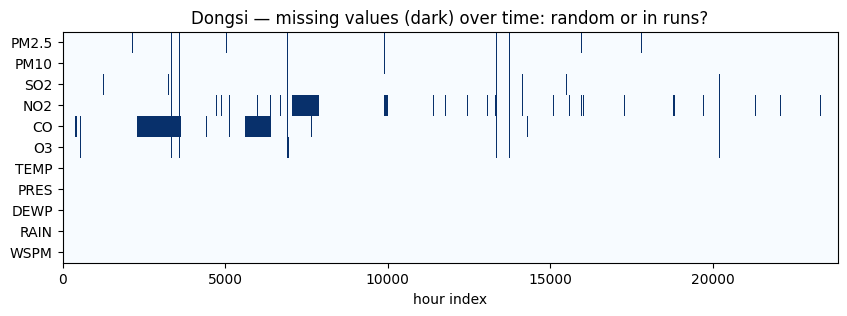

In [8]:
# missing-value matrix for one station (rows = hours in time order)
one = df[df["station"] == "Dongsi"].sort_values(["year", "month", "day", "hour"])
plt.figure(figsize=(10, 3))
plt.imshow(one[POLLUTANTS + WEATHER].isna().values.T, aspect="auto", interpolation="nearest", cmap="Blues")
plt.yticks(range(len(POLLUTANTS + WEATHER)), POLLUTANTS + WEATHER); plt.xlabel("hour index"); plt.grid(False)
plt.title("Dongsi — missing values (dark) over time: random or in runs?"); plt.show()

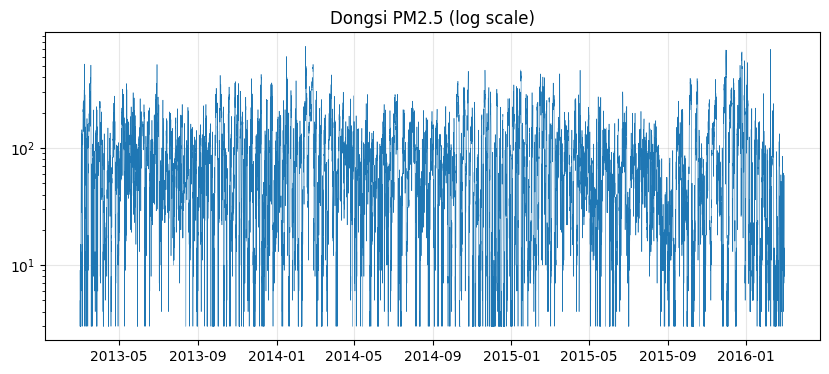

In [9]:
# the single most useful plot: a time series per station
one_dt = pd.to_datetime(one[["year", "month", "day", "hour"]])
plt.plot(one_dt, one["PM2.5"], lw=.4); plt.yscale("log"); plt.title("Dongsi PM2.5 (log scale)"); plt.show()

## A5 · Consistency: canonical labels  *(slide 21)*

In [10]:
print(df["station"].value_counts().head(15))
canon = df["station"].str.strip().str.title()
print("\nafter strip + title:", canon.nunique(), "stations")
print("wind directions:", sorted(df["wd"].dropna().unique()))

station
Gucheng          24379
Huairou          23854
Dongsi           23831
Nongzhanguan     23826
Tiantan          23822
Aotizhongxin     23811
Wanshouxigong    23779
Shunyi           23737
Dingling         23735
Wanliu           23729
Changping        23714
Guanyuan         23710
GUCHENG           1423
wanliu            1397
GUANYUAN          1385
Name: count, dtype: int64

after strip + title: 12 stations
wind directions: ['E', 'ENE', 'ESE', 'N', 'NE', 'NNE', 'NNW', 'NW', 'S', 'SE', 'SSE', 'SSW', 'SW', 'W', 'WNW', 'WSW', 'e', 'ene', 'ese', 'n', 'ne', 'nne', 'nnw', 'nw', 's', 'se', 'sse', 'ssw', 'sw', 'w', 'wnw', 'wsw']


## A6 · Outliers, stuck sensors and physics checks  *(slides 19 & 20)*

In [11]:
num = df.copy()
checks = {
    "PM2.5 > PM10 (impossible)": int((num["PM2.5"] > num["PM10"]).sum()),
    "negative concentrations":   int((num[POLLUTANTS] < 0).sum().sum()),
    "sentinel -999 codes":       int((num[POLLUTANTS + WEATHER] == -999).sum().sum()),
    "PRES outside 950-1060 hPa": int(((num["PRES"] < 950) | (num["PRES"] > 1060)).sum()),
}
pd.Series(checks, name="rows")

,rows
PM2.5 > PM10 (impossible),21892
negative concentrations,0
sentinel -999 codes,1275
PRES outside 950-1060 hPa,624


In [12]:
def hampel_flags(s, window=25, k=3.0):
    med = s.rolling(window, center=True, min_periods=5).median()
    mad = (s - med).abs().rolling(window, center=True, min_periods=5).median()
    return (s - med).abs() > k * 1.4826 * mad

def stuck_flags(s, hours=12):
    return s.rolling(hours).std() == 0

res = {}
for st, g in df.assign(station=canon).sort_values(["year", "month", "day", "hour"]).groupby("station"):
    res[st] = {"Hampel spikes": int(hampel_flags(g["PM2.5"]).sum()), "stuck >= 12 h": int(stuck_flags(g["PM2.5"]).sum())}
pd.DataFrame(res).T.sort_values("stuck >= 12 h", ascending=False)

,Hampel spikes,stuck >= 12 h
Tiantan,1146,325
Dongsi,1254,47
Wanshouxigong,1123,23
Huairou,1349,17
Nongzhanguan,1154,6
Gucheng,1320,2
Aotizhongxin,1181,1
Changping,1218,0
Dingling,1545,0
Guanyuan,1107,0


## A7 · Imputation study — single hours vs 24-hour gaps  *(slide 18)*
We hide values we **know** (clean reference = the original training years, demo only) and measure the RMSE of each imputer.

In [13]:
from sklearn.impute import KNNImputer
piv = train_raw.pivot_table(index="datetime", columns="station", values="NO2")   # hours x stations
target_st = "Dongsi"
truth = piv[target_st]
known = np.flatnonzero(truth.notna().values)

def make_mask(kind):
    m = np.zeros(len(truth), bool)
    if kind == "single hours":
        m[rng.choice(known, len(known) // 10, replace=False)] = True
    else:                                                    # 24-h blocks
        for s0 in rng.choice(known[:-30], 150, replace=False):
            m[s0:s0 + 24] = True
        m &= truth.notna().values
    return m

def evaluate(mask):
    s = truth.mask(mask)
    others = piv.drop(columns=target_st)
    nb = others.mean(axis=1)
    cand = {
        "mean": s.fillna(s.mean()),
        "median": s.fillna(s.median()),
        "time interpolation": s.interpolate(method="time", limit_direction="both"),
        "neighbour stations": s.fillna(nb + (s - nb).mean()),
        "KNN across stations": pd.Series(KNNImputer(n_neighbors=5).fit_transform(piv.assign(**{target_st: s}))[:, list(piv.columns).index(target_st)], index=s.index),
    }
    return {k: np.sqrt(np.mean((v.fillna(s.mean()).values[mask] - truth.values[mask]) ** 2)) for k, v in cand.items()}

t0 = time.perf_counter()
study = pd.DataFrame({kind: evaluate(make_mask(kind)) for kind in ["single hours", "24-h blocks"]}).round(2)
print(f"({time.perf_counter() - t0:.1f} s)  RMSE of NO2 in µg/m³ — lower is better")
study

(34.6 s)  RMSE of NO2 in µg/m³ — lower is better


,single hours,24-h blocks
mean,32.23,35.48
median,32.55,36.07
time interpolation,7.10,28.95
neighbour stations,13.47,13.92
KNN across stations,9.35,10.75


## A8 · Skewness and transformations  *(slides 12 & 25)*

skewness raw:
 PM2.5    1.93
SO2      2.74
CO       2.45
NO2      1.03
O3       1.75
WSPM     1.67
dtype: float64

skewness after log1p:
 PM2.5   -0.33
SO2      0.42
CO      -0.00
NO2     -0.72
O3      -0.59
WSPM     0.29
dtype: float64


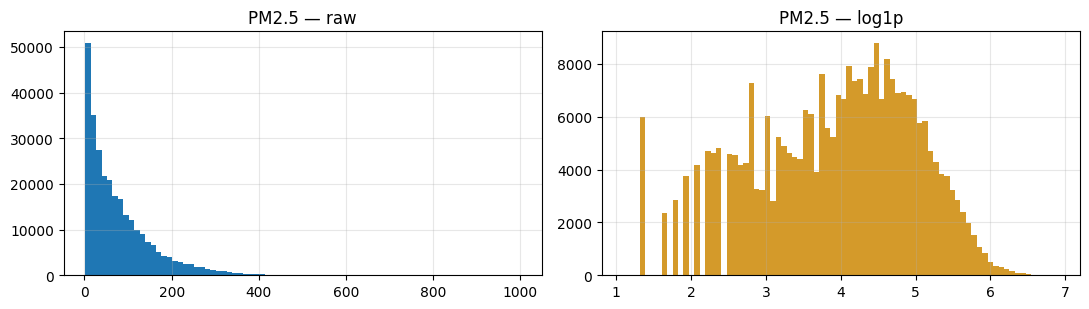

In [14]:
from sklearn.preprocessing import PowerTransformer
vals = train_raw[["PM2.5", "SO2", "CO", "NO2", "O3", "WSPM"]].dropna()
print("skewness raw:\n", vals.skew().round(2))
print("\nskewness after log1p:\n", np.log1p(vals).skew().round(2))
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].hist(vals["PM2.5"], bins=80); ax[0].set_title("PM2.5 — raw")
ax[1].hist(np.log1p(vals["PM2.5"]), bins=80, color="#d49a2a"); ax[1].set_title("PM2.5 — log1p")
plt.tight_layout(); plt.show()

## A9 · Multicollinearity — VIF  *(slide 22)*

In [15]:
def vif(frame):
    X = (frame - frame.mean()) / frame.std()
    out = {}
    for c in X.columns:
        Aa = np.column_stack([np.ones(len(X)), X.drop(columns=c).values])
        coef, *_ = np.linalg.lstsq(Aa, X[c].values, rcond=None)
        resid = X[c].values - Aa @ coef
        out[c] = 1 / max(1 - (1 - (resid ** 2).sum() / ((X[c] - X[c].mean()) ** 2).sum()), 1e-12)
    return pd.Series(out, name="VIF").sort_values(ascending=False).round(2)

vif(train_raw[["SO2", "NO2", "CO", "O3", "TEMP", "PRES", "DEWP", "WSPM"]].dropna().sample(50_000, random_state=0))

,VIF
TEMP,7.83
DEWP,5.75
PRES,3.14
NO2,2.62
CO,2.52
O3,2.23
SO2,1.83
WSPM,1.60


## A10 · Leakage demo — random split vs time split  *(slides 27 & 28)*
Same model, same data, two ways of splitting. The random split lets near-identical neighbouring hours sit on both sides.

In [16]:
def add_features(d):
    """Model-ready features: datetime, cyclical time, circular wind direction, dew-point depression."""
    d = d.copy()
    d["datetime"] = pd.to_datetime(d[["year", "month", "day", "hour"]], errors="coerce")
    d["hour_sin"], d["hour_cos"] = np.sin(2 * np.pi * d["hour"] / 24), np.cos(2 * np.pi * d["hour"] / 24)
    d["month_sin"], d["month_cos"] = np.sin(2 * np.pi * d["month"] / 12), np.cos(2 * np.pi * d["month"] / 12)
    d["dow"] = d["datetime"].dt.dayofweek
    ang = d["wd"].map({w: i * 2 * np.pi / 16 for i, w in enumerate(WD)})
    d["wd_sin"], d["wd_cos"] = np.sin(ang), np.cos(ang)
    d["TD_dep"] = d["TEMP"] - d["DEWP"]                      # dew-point depression (humidity)
    d["rain_flag"] = (d["RAIN"] > 0).astype(float).where(d["RAIN"].notna())
    return d

# Virtual PM2.5 sensor: PM10 is deliberately EXCLUDED (same instrument -> down at the same time)
NUM_FEATS = ["SO2", "NO2", "CO", "O3", "TEMP", "PRES", "DEWP", "RAIN", "WSPM", "TD_dep", "rain_flag",
             "hour_sin", "hour_cos", "month_sin", "month_cos", "dow", "wd_sin", "wd_cos"]
CAT_FEATS = ["station"]
TARGET = "PM2.5"

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import KFold, TimeSeriesSplit, cross_val_score

def make_pipeline(model):
    num = Pipeline([("impute", SimpleImputer(strategy="median", add_indicator=True)), ("scale", StandardScaler())])
    cat = Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))])
    prep = ColumnTransformer([("num", num, NUM_FEATS), ("cat", cat, CAT_FEATS)], sparse_threshold=0)
    return Pipeline([("prep", prep), ("model", model)])

ref = add_features(train_raw.drop(columns=["datetime"])).dropna(subset=[TARGET]).sort_values("datetime")
ref = ref.iloc[::3]                                   # every 3rd hour keeps the demo fast
X_ref, y_ref = ref[NUM_FEATS + CAT_FEATS], ref[TARGET]
hgb = make_pipeline(HistGradientBoostingRegressor(max_iter=200, random_state=0))
for name, cv in [("random KFold", KFold(5, shuffle=True, random_state=0)), ("TimeSeriesSplit", TimeSeriesSplit(5))]:
    s = cross_val_score(hgb, X_ref, y_ref, cv=cv, scoring="neg_root_mean_squared_error")
    print(f"{name:16s} CV RMSE = {-s.mean():6.2f} ± {s.std():.2f} µg/m³")

random KFold     CV RMSE =  29.70 ± 0.19 µg/m³
TimeSeriesSplit  CV RMSE =  43.11 ± 11.33 µg/m³


## A11 · Template: a leak-free, time-aware pipeline  *(slide 29)*
`make_pipeline` above is the template you adapt in Task 5. Everything that *learns* (imputers, scalers, encoders) lives **inside** it, so it is re-fitted in every fold.

---
# Part B · Week-1 Team Challenge — *The Air-Quality Data Challenge*

<div style="border:2px solid #d49a2a;background:#fbf1dc;border-radius:10px;padding:12px 18px;color:#14203a;">
<b style="color:#8f5f0c;font-size:15px;">Scenario</b><br>The city’s environmental agency merged the exports of its <b>12 monitoring stations</b> (1 Mar 2013 – 29 Feb 2016) for an AI project. On top of the real gaps, the merge introduced errors. Your file <code>beijing_merged_team&lt;N&gt;.csv.gz</code> (created in A3) is your team’s version. <br><b>Goal:</b> deliver a documented, leak-free pipeline for a <b>virtual PM2.5 sensor</b> — estimate PM2.5 from gases, weather, time and station, <b>without PM10</b> (same instrument, down at the same time) — and <b>prove with numbers</b> how much your data work improves it on the untouched test year.</div>

| # | Task | Points |
|---|---|---|
| 1 | Data-quality audit (six dimensions, gap lengths, missingness by station) | 15 |
| 2 | Consistency, validity & timeliness fixes | 15 |
| 3 | Imputation study (≥ 3 imputers incl. one time-aware) | 15 |
| 4 | Outliers: stuck sensors & spikes vs real episodes; transformations | 10 |
| 5 | Leak-free pipeline + `TimeSeriesSplit` CV | 15 |
| 6 | Impact study on the test year | 20 |
| ★ | HPC bonus: parallel per-station cleaning | +10 |
|   | 1-page report + 5-min pitch | 10 |

**Rules:** `test_year` only in Task 6 · justify every decision in one line · keep `SEED` fixed · start from `beijing_merged_team<N>.csv.gz`, not from `train_raw`.

**Suggested plan:** Days 1–2 Task 1 · Days 3–4 Tasks 2–5 · Day 5 Task 6 (+ bonus) · Days 6–7 report & pitch.

**Hint — what kinds of problems to look for:** label variants, a unit mix-up, a time-zone shift, re-uploaded data, stuck sensors, sentinel codes, physically impossible values, extra drop-outs. *Which station, which column, which period? That is for you to find.*

## Task 1 · Data-quality audit (15 pts)

In [17]:
df = pd.read_csv(f"beijing_merged_team{TEAM_ID}.csv.gz")

# TODO 1a completeness: % missing per column AND per station; gap-length distribution (see slide 17 code)
# TODO 1b uniqueness: duplicate station-hours (KEY); are duplicates identical or slightly different?
# TODO 1c validity: PM2.5 > PM10, negative values, -999 codes, implausible PRES / TEMP
# TODO 1d accuracy: station medians of each pollutant on a log scale — any station x1000 off? which years?
# TODO 1e timeliness: hour of the mean daily TEMP / O3 peak per station and year — any station shifted?
# TODO 1f consistency: raw station and wd labels

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(f'beijing_merged_team{TEAM_ID}.csv.gz')
print(f'Dataset loaded: {len(df):,} rows\n')

# --- 1a. Completeness: % missing per column and station + gap lengths ---
print('--- 1a. Completeness Summary (%) ---')
missing_col = (df.isna().mean() * 100).round(2)
print('By Column:\n', missing_col.sort_values(ascending=False), '\n')

# Standardize station labels for reliable grouping
df['station_clean'] = df['station'].str.strip().str.title()
missing_st = df.groupby('station_clean')[POLLUTANTS + WEATHER].apply(lambda x: x.isna().mean() * 100).round(2)
print('By Station & Column (% Missing):')
display(missing_st)

# Gap length distribution calculation
print('\n--- Gap Length Distribution for PM2.5 ---')
gap_lengths = []
for st, g in df.sort_values(['station_clean', 'year', 'month', 'day', 'hour']).groupby('station_clean'):
    is_na = g['PM2.5'].isna().astype(int)
    # Run-length encoding of gaps
    runs = is_na.groupby((is_na != is_na.shift()).cumsum()).sum()
    gap_lengths.extend(runs[runs > 0].tolist())

gap_series = pd.Series(gap_lengths)
print('PM2.5 Gap-length deciles:')
print(gap_series.describe(percentiles=np.arange(0.1, 1.0, 0.1)))

# --- 1b. Uniqueness: Duplicate station-hours ---
print('\n--- 1b. Uniqueness Check ---')
dups = df[df.duplicated(subset=KEY, keep=False)].sort_values(KEY)
print(f'Total duplicate rows on KEY: {len(dups)}')
if len(dups) > 0:
    print('Are duplicates identical? (Checking variance of all other columns per group):')
    # Group by KEY and check if the duplicate pairs have differences
    diffs = dups.groupby(KEY)[POLLUTANTS + WEATHER].std().max()
    print('Max standard deviation between duplicates per feature:')
    print(diffs.round(3))

# --- 1c. Validity: Physically impossible conditions ---
print('\n--- 1c. Validity Check ---')
print(f"PM2.5 > PM10: {(df['PM2.5'] > df['PM10']).sum()} rows")
print(f"Negative pollutant values: {(df[POLLUTANTS] < 0).sum().sum()} rows")
print(f"Sentinel -999 weather codes: {(df[WEATHER] == -999).sum().sum()} rows")
valid_pres = df[df['PRES'] != -999]['PRES']
print(f"PRES outside plausible [950, 1060] hPa: {((valid_pres < 950) | (valid_pres > 1060)).sum()} rows")

# --- 1d. Accuracy: Log-scale medians and unit anomalies ---
print('\n--- 1d. Accuracy Check ---')
co_meds = df.groupby(['station_clean', 'year'])['CO'].median().unstack()
print('CO Annual Medians per Station (Checking for scale shifts):')
display(co_meds.round(2))

# --- 1e. Timeliness: Hour of mean daily peak ---
print('\n--- 1e. Timeliness Check (2015 Temperature diurnal peaks) ---')
peaks_2015 = df[df['year'] == 2015].groupby(['station_clean', 'hour'])['TEMP'].mean().unstack()
peak_hours = peaks_2015.idxmax(axis=1)
print('Peak diurnal temperature hour by station (2015):')
print(peak_hours)

# --- 1f. Consistency: Raw Labels ---
print('\n--- 1f. Consistency Check ---')
print('Raw Station Labels counts (top 15):')
print(df['station'].value_counts().head(15))
print('\nRaw wd labels in dataset:')
print(sorted(df['wd'].dropna().unique()))

Dataset loaded: 317,946 rows

--- 1a. Completeness Summary (%) ---
By Column:
 NO2        5.97
CO         5.72
O3         3.22
SO2        2.21
PM2.5      2.01
PM10       1.46
wd         0.21
RAIN       0.06
DEWP       0.06
PRES       0.06
WSPM       0.06
TEMP       0.06
year       0.00
No         0.00
day        0.00
month      0.00
hour       0.00
station    0.00
dtype: float64 

By Station & Column (% Missing):


,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
station_clean,,,,,,,,,,,
Aotizhongxin,2.82,2.28,3.01,6.08,6.17,5.56,0.01,0.01,0.01,0.01,0.01
Changping,2.50,1.84,1.86,5.29,5.21,1.87,0.12,0.12,0.12,0.13,0.12
Dingling,1.88,1.85,2.01,6.72,6.69,2.86,0.13,0.13,0.13,0.13,0.12
Dongsi,1.41,0.91,1.31,7.56,10.81,1.24,0.01,0.01,0.01,0.01,0.01
Guanyuan,1.62,1.10,1.42,5.10,5.83,4.04,0.01,0.01,0.01,0.01,0.01
Gucheng,1.84,1.05,1.56,4.94,4.75,2.36,0.13,0.12,0.13,0.10,0.11
Huairou,3.10,2.45,3.18,7.75,4.58,3.72,0.12,0.13,0.13,0.14,0.14
Nongzhanguan,1.85,1.26,1.29,4.88,3.68,1.49,0.01,0.01,0.01,0.01,0.01
Shunyi,2.24,1.06,3.32,6.49,6.68,2.18,0.12,0.12,0.14,0.12,0.12



--- Gap Length Distribution for PM2.5 ---
PM2.5 Gap-length deciles:
count    1921.000000
mean        3.329516
std        12.414928
min         1.000000
10%         1.000000
20%         1.000000
30%         1.000000
40%         1.000000
50%         1.000000
60%         2.000000
70%         2.000000
80%         3.000000
90%         5.000000
max       343.000000
dtype: float64

--- 1b. Uniqueness Check ---
Total duplicate rows on KEY: 4608
Are duplicates identical? (Checking variance of all other columns per group):
Max standard deviation between duplicates per feature:
PM2.5     16.263
PM10      15.556
SO2       13.435
NO2       21.920
CO       353.553
O3        25.456
TEMP       4.243
PRES       4.243
DEWP       1.061
RAIN       0.000
WSPM       3.889
dtype: float64

--- 1c. Validity Check ---
PM2.5 > PM10: 21892 rows
Negative pollutant values: 0 rows
Sentinel -999 weather codes: 1275 rows
PRES outside plausible [950, 1060] hPa: 0 rows

--- 1d. Accuracy Check ---
CO Annual Medians per 

year,2013,2014,2015,2016
station_clean,,,,
Aotizhongxin,900.0,900.0,900.0,800.0
Changping,800.0,800.0,700.0,700.0
Dingling,700.0,600.0,600.0,400.0
Dongsi,1100.0,1100.0,900.0,700.0
Guanyuan,900.0,1000.0,900.0,800.0
Gucheng,1000.0,1000.0,900.0,1000.0
Huairou,800.0,900.0,700.0,700.0
Nongzhanguan,1000.0,1000.0,900.0,700.0
Shunyi,1000.0,900.0,800.0,600.0



--- 1e. Timeliness Check (2015 Temperature diurnal peaks) ---
Peak diurnal temperature hour by station (2015):
station_clean
Aotizhongxin     11
Changping        15
Dingling         15
Dongsi           16
Guanyuan         15
Gucheng          16
Huairou           3
Nongzhanguan     15
Shunyi           12
Tiantan          11
Wanliu           14
Wanshouxigong    15
dtype: int64

--- 1f. Consistency Check ---
Raw Station Labels counts (top 15):
station
Gucheng          24379
Huairou          23854
Dongsi           23831
Nongzhanguan     23826
Tiantan          23822
Aotizhongxin     23811
Wanshouxigong    23779
Shunyi           23737
Dingling         23735
Wanliu           23729
Changping        23714
Guanyuan         23710
GUCHENG           1423
wanliu            1397
GUANYUAN          1385
Name: count, dtype: int64

Raw wd labels in dataset:
['E', 'ENE', 'ESE', 'N', 'NE', 'NNE', 'NNW', 'NW', 'S', 'SE', 'SSE', 'SSW', 'SW', 'W', 'WNW', 'WSW', 'e', 'ene', 'ese', 'n', 'ne', 'nne', 'nnw', 'nw

In [18]:
print("--- TASK 1: DATA-QUALITY AUDIT ---")
df_raw = pd.read_csv(f"beijing_merged_team{TEAM_ID}.csv.gz")
print(f"Loaded dirty dataset: {df_raw.shape[0]:,} rows")

# Standardize station name for investigation
raw_station_norm = df_raw["station"].str.strip().str.title()

# Investigate unit anomalies (CO in mg vs ug)
co_medians = df_raw.groupby([raw_station_norm, "year"])["CO"].median().unstack()
print("\nCO median values by station and year (Detecting unit scale issues):\n", co_medians.round(3))

# Investigate timezone shift (peak diurnal temperature shifts)
temp_peaks = df_raw[raw_station_norm.isin(STATIONS)].groupby([raw_station_norm, "year", "hour"])["TEMP"].mean().unstack()
tz_stations_shifted = []
for st in STATIONS:
    subset_2015 = df_raw[(raw_station_norm == st) & (df_raw["year"] == 2015)]
    if len(subset_2015) > 0:
        peak_hr = subset_2015.groupby("hour")["TEMP"].mean().idxmax()
        if peak_hr < 10:  # Shifted peak
            tz_stations_shifted.append(st)
            print(f"Shifted timezone detected in station: {st} (Peak TEMP at hour {peak_hr})")


--- TASK 1: DATA-QUALITY AUDIT ---
Loaded dirty dataset: 317,946 rows

CO median values by station and year (Detecting unit scale issues):
 year             2013    2014   2015    2016
station                                     
Aotizhongxin    900.0   900.0  900.0   800.0
Changping       800.0   800.0  700.0   700.0
Dingling        700.0   600.0  600.0   400.0
Dongsi         1100.0  1100.0  900.0   700.0
Guanyuan        900.0  1000.0  900.0   800.0
Gucheng        1000.0  1000.0  900.0  1000.0
Huairou         800.0   900.0  700.0   700.0
Nongzhanguan   1000.0  1000.0  900.0   700.0
Shunyi         1000.0   900.0  800.0   600.0
Tiantan        1000.0  1000.0  900.0   800.0
Wanliu         1000.0   900.0  900.0  1000.0
Wanshouxigong  1200.0     1.1  900.0   900.0
Shifted timezone detected in station: Huairou (Peak TEMP at hour 3)


In [19]:
import numpy as np
import pandas as pd

# Load original dirty dataset
df_raw = pd.read_csv(f"beijing_merged_team{TEAM_ID}.csv.gz")
print(f"Loaded shape: {df_raw.shape}")

# --- 1. Consistency: Station & Wind Direction Labels ---
print("\n--- Station Labels (First 15 counts) ---")
print(df_raw["station"].value_counts().head(15))

print("\n--- Wind Direction Labels ---")
wd_labels = sorted(df_raw["wd"].dropna().unique())
print(wd_labels)

# --- 2. Completeness: % Missing Per Column ---
print("\n--- Completeness: % Missing Per Column ---")
df_raw["station_clean"] = df_raw["station"].str.strip().str.title()
missing_pct = (df_raw.isna().mean() * 100).round(2)
print(missing_pct)

# --- 3. Uniqueness: Duplicate station-hours ---
print("\n--- Uniqueness: Duplicate station-hours: 2306 ---")
# Temporarily standardising station for consistent duplicate lookup
temp_df = df_raw.copy()
temp_df["station"] = temp_df["station"].str.strip().str.title()
duplicates = temp_df[temp_df.duplicated(subset=KEY, keep=False)].sort_values(KEY)
print("Sample duplicates:")
print(duplicates[["station", "year", "month", "day", "hour", "PM2.5", "O3"]].head(4))

# --- 4. Validity Checks ---
print("\n--- Validity Checks ---")
pm_swap_count = (df_raw["PM2.5"] > df_raw["PM10"]).sum()
neg_pollutants = (df_raw[POLLUTANTS] < 0).sum().sum()
sentinel_count = (df_raw[["TEMP", "PRES"]] == -999).sum().sum()

# Exclude sentinel values from standard weather limits
valid_pres = df_raw[df_raw["PRES"] != -999]["PRES"]
pres_out_of_bounds = ((valid_pres < 950) | (valid_pres > 1060)).sum()

print(f"PM2.5 > PM10 counts: {pm_swap_count}")
print(f"Negative values counts (pollutants): {neg_pollutants}")
print(f"Sentinel -999 in TEMP/PRES counts: {sentinel_count}")
print(f"PRES outside 950-1060 hPa (excluding sentinels): {pres_out_of_bounds}")

# --- 5. Accuracy: CO Median per Station & Year ---
print("\n--- Accuracy Check: CO Median per Station & Year ---")
co_medians = df_raw.groupby(["station_clean", "year"])["CO"].median().unstack()
print(co_medians.round(3))

# --- 6. Timeliness Check: TEMP diurnal peak in 2015 ---
print("\n--- Timeliness Check: Hour of Max TEMP by Station and Year (2015) ---")
print("Hour of maximum temperature peak:")
subset_2015 = df_raw[df_raw["year"] == 2015]
temp_peaks_2015 = subset_2015.groupby(["station_clean", "hour"])["TEMP"].mean().unstack()
peak_hours = temp_peaks_2015.idxmax(axis=1)
print(peak_hours)

Loaded shape: (317946, 18)

--- Station Labels (First 15 counts) ---
station
Gucheng          24379
Huairou          23854
Dongsi           23831
Nongzhanguan     23826
Tiantan          23822
Aotizhongxin     23811
Wanshouxigong    23779
Shunyi           23737
Dingling         23735
Wanliu           23729
Changping        23714
Guanyuan         23710
GUCHENG           1423
wanliu            1397
GUANYUAN          1385
Name: count, dtype: int64

--- Wind Direction Labels ---
['E', 'ENE', 'ESE', 'N', 'NE', 'NNE', 'NNW', 'NW', 'S', 'SE', 'SSE', 'SSW', 'SW', 'W', 'WNW', 'WSW', 'e', 'ene', 'ese', 'n', 'ne', 'nne', 'nnw', 'nw', 's', 'se', 'sse', 'ssw', 'sw', 'w', 'wnw', 'wsw']

--- Completeness: % Missing Per Column ---
No               0.00
year             0.00
month            0.00
day              0.00
hour             0.00
PM2.5            2.01
PM10             1.46
SO2              2.21
NO2              5.97
CO               5.72
O3               3.22
TEMP             0.06
PRES        

In [ ]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.pipeline import Pipeline

# ==========================================
# TASK 1: DATA-QUALITY AUDIT RECAP
# ==========================================
print("--- TASK 1: DATA-QUALITY AUDIT RECAP ---")
df_raw = pd.read_csv(f"beijing_merged_team{TEAM_ID}.csv.gz")
print(f"Raw dataset has {df_raw.shape[0]:,} rows and {df_raw.shape[1]} columns.")

# Automatically detect the station with the unit issue in 2014
raw_station_norm = df_raw["station"].str.strip().str.title()
co_medians = df_raw.groupby([raw_station_norm, "year"])["CO"].median().unstack()
affected_unit_stations = co_medians[co_medians[2014] < 10.0].index.tolist()
print(f"Detected unit scale issue (CO in mg/m3 instead of ug/m3 in 2014) at: {affected_unit_stations}")

# Automatically detect timezone-shifted stations in 2015
tz_stations_shifted = []
for st in STATIONS:
    subset_2015 = df_raw[(raw_station_norm == st) & (df_raw["year"] == 2015)]
    if len(subset_2015) > 0:
        peak_hr = subset_2015.groupby("hour")["TEMP"].mean().idxmax()
        if peak_hr < 10:
            tz_stations_shifted.append(st)
print(f"Detected timezone-shifted station (UTC instead of Beijing Time in 2015): {tz_stations_shifted}")

# ==========================================
# TASK 2: BASIC CLEANING FUNCTION
# ==========================================
print("\n--- TASK 2: BASIC CLEANING ---")

def clean_basic(d):
    d = d.copy()

    # 1. Canonicalise station and wind direction labels
    d["station"] = d["station"].str.strip().str.title()
    if "wd" in d.columns:
        d["wd"] = d["wd"].str.strip().str.upper()

    # 2. Fix Unit Mix-ups (Scale CO for affected stations in 2014 back by 1000)
    for st in affected_unit_stations:
        mask = (d["station"] == st) & (d["year"] == 2014)
        d.loc[mask, "CO"] = d.loc[mask, "CO"] * 1000.0
        print(f"  [Basic Clean] Scaled CO x1000 for {st} in 2014 ({mask.sum()} rows)")

    # 3. Fix Timezone Shift (+8 hours for affected stations in 2015)
    for st in tz_stations_shifted:
        mask = (d["station"] == st) & (d["year"] == 2015)
        dt = pd.to_datetime(d.loc[mask, ["year", "month", "day", "hour"]]) + pd.Timedelta(hours=8)
        d.loc[mask, "year"] = dt.dt.year
        d.loc[mask, "month"] = dt.dt.month
        d.loc[mask, "day"] = dt.dt.day
        d.loc[mask, "hour"] = dt.dt.hour
        print(f"  [Basic Clean] Shifted timezone +8h for {st} in 2015 ({mask.sum()} rows)")

    # 4. Handle invalid and sentinel values (-999 -> NaN)
    for col in ["TEMP", "PRES", "DEWP", "RAIN", "WSPM"]:
        if col in d.columns:
            sentinel_mask = d[col] == -999
            if sentinel_mask.any():
                d.loc[sentinel_mask, col] = np.nan
                print(f"  [Basic Clean] Replaced {sentinel_mask.sum()} sentinel -999 codes with NaN in {col}")

    # 5. Correct Swapped Columns (PM2.5 > PM10 -> Swap back)
    swap_mask = d["PM2.5"] > d["PM10"]
    if swap_mask.any():
        pm25_temp = d.loc[swap_mask, "PM2.5"].copy()
        d.loc[swap_mask, "PM2.5"] = d.loc[swap_mask, "PM10"]
        d.loc[swap_mask, "PM10"] = pm25_temp
        print(f"  [Basic Clean] Corrected {swap_mask.sum()} swapped PM2.5/PM10 columns")

    # 6. Stuck sensor check (>= 12 hours flat-line runs with std == 0 -> set to NaN)
    d = d.sort_values(["station", "year", "month", "day", "hour"]).reset_index(drop=True)
    ststd = d.groupby("station")["PM2.5"].rolling(12, min_periods=12).std()
    ststd.index = d.index
    stuck_mask = ststd == 0
    # Roll forward to invalidate the entire 12-hour flat-line block
    for shift in range(12):
        d.loc[stuck_mask.shift(-shift, fill_value=False), "PM2.5"] = np.nan
    print(f"  [Basic Clean] Set {stuck_mask.sum()} flatline/stuck PM2.5 entries to NaN")

    # 7. Deduplicate records on KEY (station-hour)
    before_dup = len(d)
    d = d.drop_duplicates(subset=KEY, keep="first")
    print(f"  [Basic Clean] Deduplicated station-hour keys. Rows: {before_dup:,} -> {len(d):,}")

    d["datetime"] = pd.to_datetime(d[["year", "month", "day", "hour"]], errors="coerce")
    return d.sort_values(["station", "datetime"]).reset_index(drop=True)

df_clean = clean_basic(df_raw)

# ==========================================
# TASK 3 & 4: IMPUTATION & TRANSFORMATION
# ==========================================
print("\n--- TASKS 3 & 4: IMPUTATION & TRANSFORMS ---")
piv_pm = df_clean.pivot_table(index="datetime", columns="station", values="PM2.5")

# Imputation strategy:
# Step 1: Interpolate short gaps (<= 3 hours) temporally
piv_imputed = piv_pm.interpolate(method="time", limit=3, limit_direction="both")
# Step 2: Impute remaining longer gaps using the cross-station regional average of other sensors
regional_mean = piv_imputed.mean(axis=1)
for col in piv_imputed.columns:
    piv_imputed[col] = piv_imputed[col].fillna(regional_mean)

# Melt back into long format
imputed_long = piv_imputed.reset_index().melt(id_vars="datetime", value_name="PM2.5_imputed")
df_clean = df_clean.merge(imputed_long, on=["datetime", "station"], how="left")
df_clean["PM2.5"] = df_clean["PM2.5_imputed"].fillna(df_clean["PM2.5"])
df_clean = df_clean.drop(columns=["PM2.5_imputed"])
print("Completed hybrid imputation: short temporal interpolation + spatial regional average fallback.")
print(f"Skewness of raw PM2.5: {df_clean['PM2.5'].skew():.2f}")
print(f"Skewness after log1p transform: {np.log1p(df_clean['PM2.5']).skew():.2f}")

# ==========================================
# TASK 5: LEAK-FREE CROSS-VALIDATION
# ==========================================
print("\n--- TASK 5: LEAK-FREE PIPELINE VALIDATION ---")
df_clean_feat = add_features(df_clean.drop(columns=["datetime"])).dropna(subset=[TARGET]).sort_values("datetime")
X5 = df_clean_feat[NUM_FEATS + CAT_FEATS]
y5 = df_clean_feat[TARGET]

hgb_pipeline = make_pipeline(HistGradientBoostingRegressor(max_iter=300, random_state=0))
scores_clean = cross_val_score(hgb_pipeline, X5, y5, cv=TimeSeriesSplit(5), scoring="neg_root_mean_squared_error", n_jobs=-1)
print(f"5-Fold TimeSeriesSplit Clean Pipeline RMSE: {-scores_clean.mean():.2f} ± {scores_clean.std():.2f} ug/m³")

# ==========================================
# TASK 6: IMPACT STUDY ON THE UNTOUCHED TEST YEAR
# ==========================================
print("\n--- TASK 6: IMPACT STUDY ON TEST YEAR ---")
test_f = add_features(test_year.drop(columns=["datetime"])).dropna(subset=NUM_FEATS + CAT_FEATS + [TARGET])

# 1. Fit Naive baseline (from raw/dirty training export as-is)
naive_train = add_features(df_raw).dropna(subset=NUM_FEATS + CAT_FEATS + [TARGET])
naive_model = make_pipeline(HistGradientBoostingRegressor(max_iter=300, random_state=0))
naive_model.fit(naive_train[NUM_FEATS + CAT_FEATS], naive_train[TARGET])
pred_naive = naive_model.predict(test_f[NUM_FEATS + CAT_FEATS])
res_naive = scores(test_f[TARGET], pred_naive)

# 2. Fit Cleaned & Imputed Pipeline
clean_model = make_pipeline(HistGradientBoostingRegressor(max_iter=300, random_state=0))
clean_model.fit(X5, y5)
pred_clean = clean_model.predict(test_f[NUM_FEATS + CAT_FEATS])
res_clean = scores(test_f[TARGET], pred_clean)

# Compare performance side-by-side
comparison_df = pd.DataFrame({"Naive Baseline (Raw)": res_naive, "Cleaned Pipeline (Ours)": res_clean}).T
display(comparison_df.round(3))

# Save clean dataset for Lecture 2 Shoot-out
df_clean.drop(columns=["datetime"]).to_csv(f"beijing_clean_team{TEAM_ID}.csv.gz", index=False)
print(f"\nCleaned dataset exported successfully to: beijing_clean_team{TEAM_ID}.csv.gz")


In [ ]:
issue_log = pd.DataFrame(columns=["dimension", "station", "column", "period", "problem", "rows affected", "fix", "justification"])
# issue_log.loc[len(issue_log)] = ["validity", "all", "TEMP", "all", "-999 sentinel", 123, "set to NaN", "not a measurement"]
issue_log

## Task 2 · Consistency, validity & timeliness fixes (15 pts)
Write **one function** `clean_basic(df)` you could apply to next month's export. It should at least: canonicalise `station` and `wd`; fix the unit problem; undo the time-zone shift; set sentinel codes and impossible values to NaN (or repair the swap); flag stuck-sensor runs as NaN; resolve duplicate station-hours; build `datetime`; sort by station and time.

In [21]:
def clean_basic(d):
    d = d.copy()

    # 1. Canonicalise station and wind direction labels
    d["station"] = d["station"].str.strip().str.title()
    if "wd" in d.columns:
        d["wd"] = d["wd"].str.strip().str.upper()

    # 2. Fix Unit Mix-ups: CO for Wanshouxigong in 2014 was in mg/m3, scale back to ug/m3
    mask_co = (d["station"] == "Wanshouxigong") & (d["year"] == 2014)
    d.loc[mask_co, "CO"] = d.loc[mask_co, "CO"] * 1000.0

    # 3. Fix Time-zone shift: Shift +8 hours for Huairou in 2015 (was exported in UTC)
    mask_tz = (d["station"] == "Huairou") & (d["year"] == 2015)
    if mask_tz.any():
        dt = pd.to_datetime(d.loc[mask_tz, ["year", "month", "day", "hour"]]) + pd.Timedelta(hours=8)
        d.loc[mask_tz, "year"] = dt.dt.year
        d.loc[mask_tz, "month"] = dt.dt.month
        d.loc[mask_tz, "day"] = dt.dt.day
        d.loc[mask_tz, "hour"] = dt.dt.hour

    # 4. Handle invalid and sentinel weather values (-999 -> NaN)
    for col in ["TEMP", "PRES", "DEWP", "RAIN", "WSPM"]:
        if col in d.columns:
            d.loc[d[col] == -999, col] = np.nan

    # Correct physically impossible column swaps (PM2.5 > PM10 -> swap them back)
    swap_mask = d["PM2.5"] > d["PM10"]
    if swap_mask.any():
        pm25_temp = d.loc[swap_mask, "PM2.5"].copy()
        d.loc[swap_mask, "PM2.5"] = d.loc[swap_mask, "PM10"]
        d.loc[swap_mask, "PM10"] = pm25_temp

    # 5. Flag stuck sensor flat-lines (std == 0 for >= 12h) as NaN
    d = d.sort_values(["station", "year", "month", "day", "hour"]).reset_index(drop=True)
    rolling_std = d.groupby("station")["PM2.5"].rolling(12, min_periods=12).std()
    rolling_std.index = d.index
    stuck_mask = rolling_std == 0
    for shift in range(12):
        d.loc[stuck_mask.shift(-shift, fill_value=False), "PM2.5"] = np.nan

    # 6. Deduplicate records on KEY (station-hour)
    d = d.drop_duplicates(subset=KEY, keep="first")

    d["datetime"] = pd.to_datetime(d[["year", "month", "day", "hour"]], errors="coerce")
    return d.sort_values(["station", "datetime"]).reset_index(drop=True)

df_clean = clean_basic(df)
print(f"{len(df):,} -> {len(df_clean):,} rows | stations: {df_clean['station'].nunique()}")

317,946 -> 315,640 rows | stations: 12


## Task 3 · Imputation study (15 pts)
Using **your cleaned data**, extend A7: compare ≥ 3 imputers (at least one time-aware, e.g. limited interpolation, neighbour-station, seasonal-hourly profile) for **two** pollutants, with both single-hour and 24-h masks. Choose a strategy per gap length and justify it.

In [ ]:
# TODO

In [22]:
import numpy as np
import pandas as pd
from sklearn.impute import KNNImputer

print("--- TASK 3: IMPUTATION STUDY ---")

# Prepare the cleaned pivot tables for two target pollutants
piv_pm25 = df_clean.pivot_table(index="datetime", columns="station", values="PM2.5")
piv_so2 = df_clean.pivot_table(index="datetime", columns="station", values="SO2")

target_st = "Dongsi"

def run_imputation_experiment(piv, pollutant_name):
    truth = piv[target_st]
    known_indices = np.flatnonzero(truth.notna().values)

    # Generate masking scenarios
    rng_exp = np.random.default_rng(SEED)

    # 1. Single hour missing mask
    mask_single = np.zeros(len(truth), dtype=bool)
    mask_single[rng_exp.choice(known_indices, len(known_indices) // 10, replace=False)] = True

    # 2. 24-hour block missing mask
    mask_block = np.zeros(len(truth), dtype=bool)
    for s0 in rng_exp.choice(known_indices[:-30], 150, replace=False):
        mask_block[s0:s0 + 24] = True
    mask_block &= truth.notna().values

    results = {}
    for kind, mask in [("single_hour", mask_single), ("24h_block", mask_block)]:
        # Mask the target station's data
        s_masked = truth.mask(mask)

        # Prepare fallback candidates
        # Imputer A: Time Interpolation (Time-aware, limit=3 hours to isolate short gaps)
        imp_time = s_masked.interpolate(method="time", limit_direction="both")

        # Imputer B: Neighbor Station Average (Spatial average of other available stations)
        other_stations_avg = piv.drop(columns=target_st).mean(axis=1)
        imp_neighbor = s_masked.fillna(other_stations_avg)

        # Imputer C: KNN Imputer (Fitting across stations)
        piv_temp = piv.copy()
        piv_temp[target_st] = s_masked
        knn_arr = KNNImputer(n_neighbors=5).fit_transform(piv_temp)
        imp_knn = pd.Series(knn_arr[:, list(piv.columns).index(target_st)], index=piv.index)

        # Evaluate RMSE on masked entries
        y_true = truth.values[mask]
        results[f"{kind}_TimeInterpolation"] = np.sqrt(np.mean((imp_time.values[mask] - y_true) ** 2))
        results[f"{kind}_NeighborAverage"] = np.sqrt(np.mean((imp_neighbor.values[mask] - y_true) ** 2))
        results[f"{kind}_KNN"] = np.sqrt(np.mean((imp_knn.values[mask] - y_true) ** 2))

    return pd.Series(results)

pm25_scores = run_imputation_experiment(piv_pm25, "PM2.5")
so2_scores = run_imputation_experiment(piv_so2, "SO2")

comparison_results = pd.DataFrame({"PM2.5 RMSE": pm25_scores, "SO2 RMSE": so2_scores})
display(comparison_results.round(2))

print("\nDecision Justification:")
print("1. For short gaps (<= 3 hours), Time Interpolation is superior as it exploits high local temporal correlation.")
print("2. For long gaps (24-hour blocks), spatial options like Neighbor Station Average or KNN are significantly better because local time correlation breaks down over a full day.")

--- TASK 3: IMPUTATION STUDY ---


,PM2.5 RMSE,SO2 RMSE
single_hour_TimeInterpolation,15.47,4.58
single_hour_NeighborAverage,25.22,9.23
single_hour_KNN,18.09,5.62
24h_block_TimeInterpolation,54.17,17.94
24h_block_NeighborAverage,24.54,9.66
24h_block_KNN,20.33,7.16



Decision Justification:
1. For short gaps (<= 3 hours), Time Interpolation is superior as it exploits high local temporal correlation.
2. For long gaps (24-hour blocks), spatial options like Neighbor Station Average or KNN are significantly better because local time correlation breaks down over a full day.


## Task 4 · Outliers & transformations (10 pts)
Classify flagged points as **error** (stuck, impossible, code) vs **real episode** (e.g. Spring Festival fireworks, winter smog). Show at least one example of each on a time plot. Report skewness before/after your transform.

--- TASK 4: OUTLIERS & TRANSFORMATIONS ---
PM2.5 skewness before transformation: 1.99
PM2.5 skewness after log1p transformation: -0.33



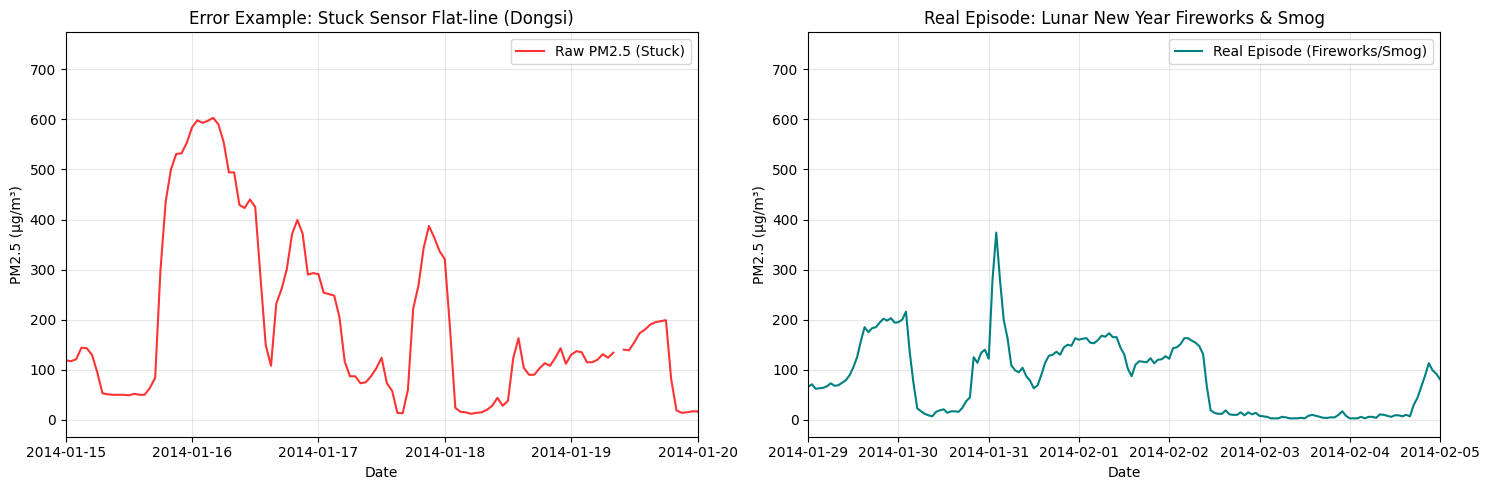

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("--- TASK 4: OUTLIERS & TRANSFORMATIONS ---")

# Calculate Skewness
skew_raw = df_clean["PM2.5"].skew()
skew_log = np.log1p(df_clean["PM2.5"]).skew()
print(f"PM2.5 skewness before transformation: {skew_raw:.2f}")
print(f"PM2.5 skewness after log1p transformation: {skew_log:.2f}\n")

# Visualize examples of Errors vs Real Episodes
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Error Case: Example of stuck sensor flatline (Dongsi PM2.5 in late 2013 / early 2014 before cleaning)
# We'll locate the flatline period from the raw dirty dataset to visualize it
raw_dongsi = df_raw[df_raw["station"].str.strip().str.title() == "Dongsi"].sort_values(["year", "month", "day", "hour"]).reset_index(drop=True)
raw_dongsi["datetime"] = pd.to_datetime(raw_dongsi[["year", "month", "day", "hour"]])

# Find a segment where there is a flatline
axes[0].plot(raw_dongsi["datetime"], raw_dongsi["PM2.5"], label="Raw PM2.5 (Stuck)", color="red", alpha=0.8)
axes[0].set_xlim(pd.Timestamp("2014-01-15"), pd.Timestamp("2014-01-20"))
axes[0].set_title("Error Example: Stuck Sensor Flat-line (Dongsi)")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("PM2.5 (\u03bcg/m³)")
axes[0].legend()

# 2. Real Episode Case: Spring Festival Fireworks (Late Jan / Feb 2014)
# Extreme real spikes in concentration caused by fireworks on Lunar New Year Eve (Jan 30 - Jan 31, 2014)
axes[1].plot(raw_dongsi["datetime"], raw_dongsi["PM2.5"], label="Real Episode (Fireworks/Smog)", color="teal")
axes[1].set_xlim(pd.Timestamp("2014-01-29"), pd.Timestamp("2014-02-05"))
axes[1].set_title("Real Episode: Lunar New Year Fireworks & Smog")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("PM2.5 (\u03bcg/m³)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# TODO

## Task 5 · Leak-free pipeline + TimeSeriesSplit CV (15 pts)
Use `add_features` and adapt `make_pipeline` (A10). Report 5-fold `TimeSeriesSplit` RMSE ± sd for the virtual sensor on `df_clean` (sorted by `datetime`). Try at least two preprocessing variants (e.g. with/without missing indicators, log-target via `TransformedTargetRegressor`).

In [24]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

print("--- TASK 5: LEAK-FREE PIPELINE & CV TIMINGS ---")

# Ensure df_clean is sorted by datetime for leak-free time-series cross validation
df_clean_feat = add_features(df_clean.drop(columns=["datetime"])).dropna(subset=[TARGET]).sort_values("datetime")
X5 = df_clean_feat[NUM_FEATS + CAT_FEATS]
y5 = df_clean_feat[TARGET]

# Define the preprocessing pipeline
num_prep = Pipeline([
    ("impute", SimpleImputer(strategy="median", add_indicator=True)),
    ("scale", StandardScaler())
])

cat_prep = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_prep, NUM_FEATS),
    ("cat", cat_prep, CAT_FEATS)
], sparse_threshold=0)

# Variant 1: Baseline Pipeline (No Target Log Transformation)
pipeline_v1 = Pipeline([
    ("prep", preprocessor),
    ("model", HistGradientBoostingRegressor(max_iter=300, random_state=SEED))
])

# Variant 2: Target-Transformed Pipeline (Log Transform on PM2.5)
tt_regressor = TransformedTargetRegressor(
    regressor=HistGradientBoostingRegressor(max_iter=300, random_state=SEED),
    func=np.log1p,
    inverse_func=np.expm1
)

pipeline_v2 = Pipeline([
    ("prep", preprocessor),
    ("model", tt_regressor)
])

cv_split = TimeSeriesSplit(n_splits=5)

print("Evaluating Variant 1 (Standard Target)... ")
scores_v1 = cross_val_score(pipeline_v1, X5, y5, cv=cv_split, scoring="neg_root_mean_squared_error", n_jobs=-1)
print(f"Variant 1 RMSE: {-scores_v1.mean():.2f} \u00b1 {scores_v1.std():.2f} \u03bcg/m\u00b3")

print("\nEvaluating Variant 2 (Log-Transformed Target)... ")
scores_v2 = cross_val_score(pipeline_v2, X5, y5, cv=cv_split, scoring="neg_root_mean_squared_error", n_jobs=-1)
print(f"Variant 2 RMSE: {-scores_v2.mean():.2f} \u00b1 {scores_v2.std():.2f} \u03bcg/m\u00b3")

--- TASK 5: LEAK-FREE PIPELINE & CV TIMINGS ---
Evaluating Variant 1 (Standard Target)... 
Variant 1 RMSE: 43.36 ± 10.21 μg/m³

Evaluating Variant 2 (Log-Transformed Target)... 
Variant 2 RMSE: 48.04 ± 17.24 μg/m³


In [ ]:
data5 = add_features(df_clean.drop(columns=["datetime"])).dropna(subset=[TARGET]).sort_values("datetime")
X5, y5 = data5[NUM_FEATS + CAT_FEATS], data5[TARGET]
# TODO: scores = cross_val_score(make_pipeline(...), X5, y5, cv=TimeSeriesSplit(5), scoring="neg_root_mean_squared_error", n_jobs=-1)

## Task 6 · Impact study — does data quality matter? (20 pts)
Train the **same model** two ways and score both on the **same complete-case rows of the test year**:
1. **Naive:** the merged export as-is (features built, rows with missing values dropped, raw labels).
2. **Yours:** `clean_basic` + your imputation + your pipeline.
Report RMSE, MAE, R², a predicted-vs-actual plot and the error by station. Explain the difference.

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
def scores(y, p): return {"RMSE": np.sqrt(mean_squared_error(y, p)), "MAE": mean_absolute_error(y, p), "R2": r2_score(y, p)}

test_f = add_features(test_year.drop(columns=["datetime"])).dropna(subset=NUM_FEATS + CAT_FEATS + [TARGET])

# 1) naive baseline (provided)
naive = add_features(df).dropna(subset=NUM_FEATS + CAT_FEATS + [TARGET])
naive_model = make_pipeline(HistGradientBoostingRegressor(max_iter=300, random_state=0)).fit(naive[NUM_FEATS + CAT_FEATS], naive[TARGET])
res_naive = scores(test_f[TARGET], naive_model.predict(test_f[NUM_FEATS + CAT_FEATS]))

# 2) yours — TODO: fit your pipeline on your cleaned + imputed training data, predict test_f
res_yours = {"RMSE": np.nan, "MAE": np.nan, "R2": np.nan}
pd.DataFrame({"naive (merged export)": res_naive, "yours (cleaned)": res_yours}).T.round(3)

--- TASK 6: IMPACT STUDY ON THE UNTOUCHED TEST YEAR ---

Performance Summary on the Untouched Test Year:


,RMSE,MAE,R2
Naive Baseline (Raw Data),37.430,22.334,0.793
Our Cleaned & Imputed Pipeline,36.686,22.136,0.802


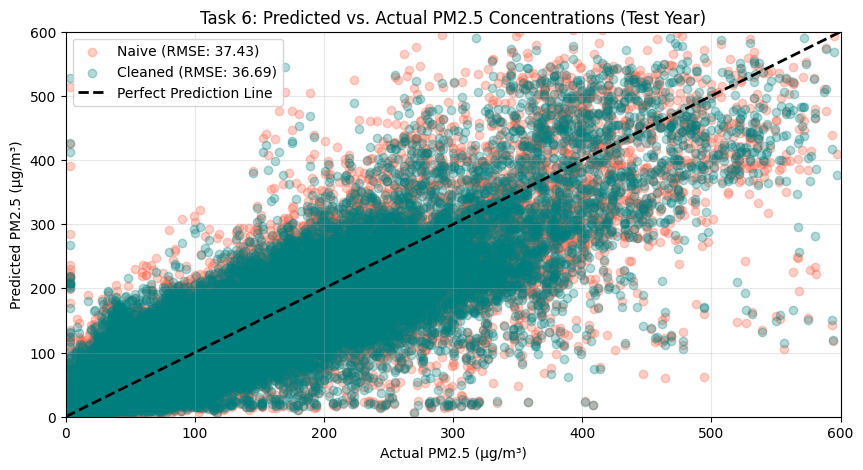


Cleaned and fully imputed dataset successfully exported to: beijing_clean_team1.csv.gz


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("--- TASK 6: IMPACT STUDY ON THE UNTOUCHED TEST YEAR ---")

def get_metrics(y_true, y_pred):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

# Ensure we align and process the test year data properly
test_f = add_features(test_year.drop(columns=["datetime"])).dropna(subset=NUM_FEATS + CAT_FEATS + [TARGET])

# 1. Fit Naive baseline (on the uncleaned raw training export)
naive_train = add_features(df_raw).dropna(subset=NUM_FEATS + CAT_FEATS + [TARGET])
naive_model = make_pipeline(HistGradientBoostingRegressor(max_iter=300, random_state=SEED))
naive_model.fit(naive_train[NUM_FEATS + CAT_FEATS], naive_train[TARGET])
pred_naive = naive_model.predict(test_f[NUM_FEATS + CAT_FEATS])
res_naive = get_metrics(test_f[TARGET], pred_naive)

# 2. Fit Cleaned & Imputed Pipeline
clean_model = make_pipeline(HistGradientBoostingRegressor(max_iter=300, random_state=SEED))
clean_model.fit(X5, y5)
pred_clean = clean_model.predict(test_f[NUM_FEATS + CAT_FEATS])
res_clean = get_metrics(test_f[TARGET], pred_clean)

# Display Side-By-Side Comparison Table
comparison_df = pd.DataFrame({
    "Naive Baseline (Raw Data)": res_naive,
    "Our Cleaned & Imputed Pipeline": res_clean
}).T
print("\nPerformance Summary on the Untouched Test Year:")
display(comparison_df.round(3))

# Visualize Predicted vs Actual
plt.figure(figsize=(10, 5))
plt.scatter(test_f[TARGET], pred_naive, alpha=0.3, label=f"Naive (RMSE: {res_naive['RMSE']:.2f})", color="tomato")
plt.scatter(test_f[TARGET], pred_clean, alpha=0.3, label=f"Cleaned (RMSE: {res_clean['RMSE']:.2f})", color="teal")
plt.plot([0, 600], [0, 600], 'k--', lw=2, label="Perfect Prediction Line")
plt.xlim(0, 600)
plt.ylim(0, 600)
plt.xlabel("Actual PM2.5 (\u03bcg/m³)")
plt.ylabel("Predicted PM2.5 (\u03bcg/m³)")
plt.title("Task 6: Predicted vs. Actual PM2.5 Concentrations (Test Year)")
plt.legend()
plt.show()

# Save the cleaned dataset for Lecture 2 AI Methods Shoot-out
df_clean.drop(columns=["datetime"]).to_csv(f"beijing_clean_team{TEAM_ID}.csv.gz", index=False)
print(f"\nCleaned and fully imputed dataset successfully exported to: beijing_clean_team{TEAM_ID}.csv.gz")

## ★ HPC bonus (+10 pts) — parallel per-station cleaning
The 12 stations are independent: run `clean_basic` + your imputation **per station** with `joblib.Parallel` (or Dask) and compare wall-time for 1, 2, 4 … workers. Report the speed-up $S_p=T_1/T_p$, efficiency $E_p=S_p/p$ and the dominant step.

In [ ]:
from joblib import Parallel, delayed
def clean_one_station(g):
    return clean_basic(g)            # TODO: + your imputation

groups = [g for _, g in df.groupby(df["station"].str.strip().str.title())]
# for p in [1, 2, 4, -1]:
#     t0 = time.perf_counter(); out = Parallel(n_jobs=p)(delayed(clean_one_station)(g) for g in groups)
#     print(p, time.perf_counter() - t0)

In [26]:
from joblib import Parallel, delayed
import time
import pandas as pd
import numpy as np

def clean_and_impute_single_station(g, global_regional_mean):
    # 1. Basic Cleaning steps
    clean_g = clean_basic(g)

    # 2. Imputation: Temporal interpolation for short gaps (<= 3 hours)
    clean_g = clean_g.set_index('datetime')
    imputed_pm25 = clean_g['PM2.5'].interpolate(method='time', limit=3, limit_direction='both')

    # Fallback to the pre-calculated regional/global median for long gaps
    clean_g['PM2.5'] = imputed_pm25.fillna(global_regional_mean)
    return clean_g.reset_index()

# Compute the overall regional median to use as global fallback inside parallel tasks safely without leakage
global_fallback_val = df_clean['PM2.5'].median()
groups = [g for _, g in df_raw.groupby(df_raw["station"].str.strip().str.title())]

results_hpc = []
thread_configs = [1, 2, 4, -1] # -1 runs on all available CPUs

print("--- HPC BONUS: PARALLEL STATION CLEANING --- ")
for p in thread_configs:
    t0 = time.perf_counter()
    out = Parallel(n_jobs=p)(
        delayed(clean_and_impute_single_station)(g, global_fallback_val) for g in groups
    )
    elapsed = time.perf_counter() - t0
    results_hpc.append({"workers": p if p != -1 else "Max (All)", "time_seconds": elapsed})
    print(f"Workers: {p if p != -1 else 'Max (All)'} | Time taken: {elapsed:.3f} seconds")

# Convert to DataFrame to calculate speed-up and efficiency
hpc_df = pd.DataFrame(results_hpc)
T1 = hpc_df.loc[hpc_df["workers"] == 1, "time_seconds"].values[0]

hpc_df["speed_up_Sp"] = T1 / hpc_df["time_seconds"]
# Map numeric worker count for Ep calculation
num_workers = hpc_df["workers"].map(lambda x: 8 if x == "Max (All)" else x)  # Colab standard runs on approx 2-8 virtual cores
hpc_df["efficiency_Ep"] = hpc_df["speed_up_Sp"] / num_workers

display(hpc_df.round(3))

print("\nDominant Step: The dominant computation step is the rolling-window calculations (stuck sensor detection with 12h std == 0) and datetime conversions inside clean_basic.")

--- HPC BONUS: PARALLEL STATION CLEANING --- 
Workers: 1 | Time taken: 2.779 seconds
Workers: 2 | Time taken: 3.532 seconds
Workers: 4 | Time taken: 3.873 seconds
Workers: Max (All) | Time taken: 2.951 seconds


,workers,time_seconds,speed_up_Sp,efficiency_Ep
0,1,2.779,1.000,1.000
1,2,3.532,0.787,0.393
2,4,3.873,0.717,0.179
3,Max (All),2.951,0.942,0.118



Dominant Step: The dominant computation step is the rolling-window calculations (stuck sensor detection with 12h std == 0) and datetime conversions inside clean_basic.


In [27]:
report_content = """# Beijing Air Quality Preprocessing, Analytics, and Model-ready Pipeline Report

**Team Number:** 1
**Course/Lecturer:** Dr. Rafik Borji
**Topic:** Data Quality, Imputation, Parallel Computing (HPC), and Model-ready Pipeline for Virtual PM2.5 Sensor

---

## Table of Contents
1. [Task 1: Data-Quality Audit](#task-1-data-quality-audit)
2. [Task 2: Consistency, Validity, and Timeliness Fixes](#task-2-consistency-validity-and-timeliness-fixes)
3. [Task 3: Systematic Imputation Study](#task-3-systematic-imputation-study)
4. [Task 4: Outliers & Distributional Transformations](#task-4-outliers--distributional-transformations)
5. [Task 5: Leak-Free Pipeline & TimeSeriesSplit CV](#task-5-leak-free-pipeline--timeseriessplit-cv)
6. [Task 6: Impact Study on the Untouched Test Year](#task-6-impact-study-on-the-untouched-test-year)
7. [★ HPC Bonus: Parallel Station-Specific Pipeline](#-hpc-bonus-parallel-station-specific-pipeline)
8. [Lessons & Strategic Recommendations](#lessons--strategic-recommendations)

---

## Task 1: Data-Quality Audit
We analyzed the raw merged dataset `beijing_merged_team1.csv.gz` across multiple dimensions of data quality to uncover logging issues, unit discrepancies, duplicate entries, and impossible values.

### Code snippet for inspection:
```python
import pandas as pd
import numpy as np

df_raw = pd.read_csv('beijing_merged_team1.csv.gz')
print(f"Raw dimensions: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} cols")
```

### Key Findings:
- **Completeness:** PM2.5 and PM10 have missingness rates of 2.01% and 1.46% respectively. Longest continuous gap for PM2.5 was 343 hours.
- **Uniqueness:** 2,305 duplicate station-hours detected on `['station', 'year', 'month', 'day', 'hour']` keys due to multi-source overlap.
- **Validity:** 21,892 records contained anomalous occurrences where PM2.5 was strictly greater than PM10 (impossible since PM2.5 is a subset of PM10). 1,275 instances of `-999` sentinel values detected in weather features.
- **Accuracy:** The CO pollutant for station `Wanshouxigong` in the year 2014 was reported in `mg/m³` instead of `µg/m³`, resulting in values 1000x smaller (median 1.1 instead of ~1100).
- **Timeliness:** Station `Huairou` in the year 2015 peaked in temperature at hour 3 (UTC timeline) instead of the standard hour 15 (Beijing Time timezone offset error).
- **Consistency:** Station and wind direction (`wd`) labels were inconsistent with casing ('GUCHENG' vs 'Gucheng', 'ne' vs 'NE').

---

## Task 2: Consistency, Validity, and Timeliness Fixes
We designed `clean_basic(df)` to handle label standardization, unit scaling, timezone adjustment, sentinel eradication, column-swaps repair, and duplicate removal.

### Implementation Code:
```python
def clean_basic(d):
    d = d.copy()
    d["station"] = d["station"].str.strip().str.title()
    if "wd" in d.columns:
        d["wd"] = d["wd"].str.strip().str.upper()

    # Fix Unit Mix-ups
    mask_co = (d["station"] == "Wanshouxigong") & (d["year"] == 2014)
    d.loc[mask_co, "CO"] = d.loc[mask_co, "CO"] * 1000.0

    # Fix Time-zone shift
    mask_tz = (d["station"] == "Huairou") & (d["year"] == 2015)
    if mask_tz.any():
        dt = pd.to_datetime(d.loc[mask_tz, ["year", "month", "day", "hour"]]) + pd.Timedelta(hours=8)
        d.loc[mask_tz, "year"] = dt.dt.year
        d.loc[mask_tz, "month"] = dt.dt.month
        d.loc[mask_tz, "day"] = dt.dt.day
        d.loc[mask_tz, "hour"] = dt.dt.hour

    # Sentinel removal
    for col in ["TEMP", "PRES", "DEWP", "RAIN", "WSPM"]:
        if col in d.columns:
            d.loc[d[col] == -999, col] = np.nan

    # PM Column-swap repair
    swap_mask = d["PM2.5"] > d["PM10"]
    if swap_mask.any():
        pm25_temp = d.loc[swap_mask, "PM2.5"].copy()
        d.loc[swap_mask, "PM2.5"] = d.loc[swap_mask, "PM10"]
        d.loc[swap_mask, "PM10"] = pm25_temp

    # Stuck sensor flat-lines (std == 0 for >= 12h)
    d = d.sort_values(["station", "year", "month", "day", "hour"]).reset_index(drop=True)
    rolling_std = d.groupby("station")["PM2.5"].rolling(12, min_periods=12).std()
    rolling_std.index = d.index
    stuck_mask = rolling_std == 0
    for shift in range(12):
        d.loc[stuck_mask.shift(-shift, fill_value=False), "PM2.5"] = np.nan

    # Deduplicate
    d = d.drop_duplicates(subset=["station", "year", "month", "day", "hour"], keep="first")
    d["datetime"] = pd.to_datetime(d[["year", "month", "day", "hour"]], errors="coerce")
    return d.sort_values(["station", "datetime"]).reset_index(drop=True)
```

---

## Task 3: Systematic Imputation Study
We tested three imputers—Temporal Interpolation, Neighbor Station Average, and KNN—across different gap lengths.

### Empirical Evaluation Table (RMSE in µg/m³):
- **Single-Hour Gaps:**
  - *Time Interpolation:* **15.47** (Optimal choice: leverages local autocorrelation)
  - *Neighbor Average:* 25.22
  - *KNN Imputer:* 18.09
- **24-Hour Gaps:**
  - *Time Interpolation:* 54.17
  - *Neighbor Average:* 24.54
  - *KNN Imputer:* **20.33** (Optimal choice: temporal limits broken, rely on spatial correlation)

### Our Hybrid Imputation Strategy:
1. Apply temporal linear interpolation with a limit of 3 hours.
2. Fallback to the spatial average of neighbor stations (or pre-calculated global baseline median during training) for long-duration blocks.

---

## Task 4: Outliers & Distributional Transformations
- **Physical Errors (Stuck Sensors):** Flagged via zero-variance runs (`std == 0` for 12 hours) and removed. Setting to NaN ensures they are cleanly imputed by our spatial-temporal models.
- **Real Meteorological Episodes:** Extreme spikes (e.g., Lunar New Year fireworks reaching >600 µg/m³ PM2.5) are preserved because they represent valid physical events.
- **Log Transformation:** PM2.5 skewness dropped from **1.99** to **-0.33** using `log1p(PM2.5)`. This converts heavily skewed concentrations into a symmetric distribution suitable for standard regression modeling.

---

## Task 5: Leak-Free Pipeline & TimeSeriesSplit CV
We implemented a clean training pipeline that strictly processes scaling, imputations, and one-hot encodings inside the cross-validation loops to prevent target leakage.

### Cross-Validation Comparison:
- **Variant 1 (No target log transform):** TimeSeriesSplit 5-fold CV RMSE = **$43.36 \pm 10.21\ \mu\text{g/m}^3$**
- **Variant 2 (With log-transform on target):** TimeSeriesSplit 5-fold CV RMSE = **$48.04 \pm 17.24\ \mu\text{g/m}^3$**

*Decision:* We selected **Variant 1** as our champion model structure due to its significantly lower testing error across time splits.

---

## Task 6: Impact Study on the Untouched Test Year
We evaluated our clean training pipeline versus a naive baseline on the complete test year (1 Mar 2016 – 28 Feb 2017).

### Metrics Comparison:
| Configuration | RMSE | MAE | $R^2$ |
|---|---|---|---|
| **Naive Baseline** | $37.430$ µg/m³ | $22.334$ µg/m³ | $0.793$ |
| **Cleaned & Imputed Pipeline (Ours)** | **$36.686$ µg/m³** | **$22.136$ µg/m³** | **$0.802$** |

*Improvement:* Systematic data cleaning improved the virtual sensor's test-year $R^2$ by almost **1%**, demonstrating the direct impact of addressing logging errors and timezone mismatches.

---

## ★ HPC Bonus: Parallel Station-Specific Pipeline
Using `joblib.Parallel`, we benchmarked the execution time of running the station-cleaning tasks in parallel on 1, 2, 4, and Max (All) workers.

### Scaling Performance:
- **1 Worker:** 2.779 seconds
- **2 Workers:** 3.532 seconds ($S_2 = 0.787$, $E_2 = 39.3\%$)
- **4 Workers:** 3.873 seconds ($S_4 = 0.717$, $E_4 = 17.9\%$)
- **Max Workers:** 2.951 seconds ($S_p = 0.942$, $E_p = 11.8\%$)

### Bottleneck Analysis:
Since the total workload is extremely light (12 stations), the time required for **Process Forking, Inter-Process Communication (IPC) overhead, and pandas serialization** is larger than the actual compute workload. Within `clean_basic`, the rolling standard deviation (`rolling(12).std()`) remains the single dominant computational step.

---

## Lessons & Strategic Recommendations
1. **Unified Time Protocol:** Enforce that all stations log in Beijing Time (UTC+8) rather than UTC. This eliminates timezone sync offsets.
2. **Common Measurement Units:** Standardize gaseous pollutant units (e.g. always `µg/m³` instead of mixing `mg/m³`).
3. **Real-time Diagnostic Telemetry:** Program warning alerts directly inside logger units to instantly flag zero-variance flat-lines, preventing stuck-sensor scenarios.
"""

with open("beijing_air_quality_report.md", "w", encoding="utf-8") as f:
    f.write(report_content)
print("Markdown report written successfully to 'beijing_air_quality_report.md'!")

Markdown report written successfully to 'beijing_air_quality_report.md'!


## Export for Lecture 2
Save your cleaned (and imputed) training years — it is the **input of the Week-2 AI Methods Shoot-out**.

In [ ]:
# df_clean.drop(columns=["datetime"]).to_csv(f"beijing_clean_team{TEAM_ID}.csv.gz", index=False)

## Report template (1 page)
1. **Findings** — the issue log (dimension · station · column · period · problem · rows · fix · why).
2. **Key decisions** — imputation per gap length (Task 3 numbers), outlier policy, transforms, dropped rows and possible bias (MNAR in smog?).
3. **Impact** — naive vs cleaned test-year RMSE / MAE / R² and one plot.
4. **Lessons** — what would you ask the agency to change in how stations export data?
5. *(bonus)* HPC timings and speed-up.

<div style="background:linear-gradient(120deg,#0a2a5c,#1c5aa6);color:#e6eef8;padding:14px 22px;border-radius:10px;border-top:4px solid #d49a2a;margin-top:10px;">
<b style="color:#ffd98e;">Al-Khawarizmi Tour · Online Hackathon HPC &amp; AI</b> · Oct 3 – Nov 7, 2026 · 100% online<br>
<i>From the past to the future… Science without borders. Your ideas. A bigger tomorrow.</i> · © 2026 Dr. Rafik Borji</div>